In [1]:
# Import necessary libraries for data manipulation, machine learning, and visualization
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np


In [2]:
# Load data files
attempts = pd.read_csv("attempts_at_goal_team.csv")
fifa_stats = pd.read_csv("FIFA_Site_Team_Stats.csv")
rounds2026 = pd.read_csv("rounds2026.csv")


# Inspect data structure and quality
attempts.info()
fifa_stats.info()
rounds2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   rank                              48 non-null     int64  
 1   team_id                           48 non-null     int64  
 2   team                              48 non-null     str    
 3   team_abbrv                        48 non-null     str    
 4   goals                             48 non-null     int64  
 5   assists                           48 non-null     int64  
 6   attempt_at_goal                   48 non-null     int64  
 7   attempt_ontarget                  48 non-null     int64  
 8   offtarget_attempt                 48 non-null     int64  
 9   attempt_goal_convRate_percentage  48 non-null     int64  
 10  attempt_inside_pa                 48 non-null     int64  
 11  attempt_outside_pa                48 non-null     int64  
 12  headed_attempt_goal  

In [3]:
# Standardise column names for consistency
attempts_renamed = attempts.rename(columns={
    "team": "Team",
    "team_abbrv": "TeamAbbr",
    "goals": "Goals",
    "assists": "Assists",
    "attempt_at_goal": "Attempts_at_goal",
    "attempt_ontarget": "Attempts_on_target",
    "offtarget_attempt": "Off_Target_Attempts",
    "attempt_goal_convRate_percentage": "Attempts_at_goal_conversionrate(%)",
    "attempt_inside_pa": "Attempts_Inside_PenaltyArea",
    "attempt_outside_pa": "Attemps_Outside_PenaltyArea",
    "headed_attempt_goal": "Headed_Attemps_at_Goal",
    "xG": "xG",
    "xG_efficiency": "xG_Efficiency",
    "corners": "Corners",
    "possession_control_percentage": "Possession_Control(%)"
})

# Create a copy of the renamed attempts dataframe for further analysis
team_stats = attempts_renamed.copy()

In [13]:
# Keep only matches with complete score data
matches = rounds2026.dropna(subset=["homeScore", "awayScore"].copy())

matches.head()
matches.info()

# Print the number of matches with complete score data
print("Number of matches with scores: ", len(matches))

# Calculate the goal difference for each match
matches_len = len(matches)
matches["goal_diff"] = matches["homeScore"] - matches["awayScore"]


<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 104 non-null    int64
 1   voteStatus         104 non-null    str  
 2   stage              104 non-null    str  
 3   roundName          104 non-null    str  
 4   votingStartDate    104 non-null    str  
 5   votingEndDate      104 non-null    str  
 6   votingOpenedAt     104 non-null    str  
 7   selectedFormation  2 non-null      str  
 8   winners            104 non-null    str  
 9   formations         2 non-null      str  
 10  id.1               104 non-null    int64
 11  venueName          104 non-null    str  
 12  venueCity          104 non-null    str  
 13  venueId            104 non-null    int64
 14  date               104 non-null    str  
 15  homeSquadId        104 non-null    int64
 16  awaySquadId        104 non-null    int64
 17  homeSquadName      104 non-

In [14]:
# Merge match data with home team statistics
home = matches.merge(
    team_stats,
    left_on="homeSquadAbbr",
    right_on="TeamAbbr",
    how="left",
    suffixes=("", "_home")
)


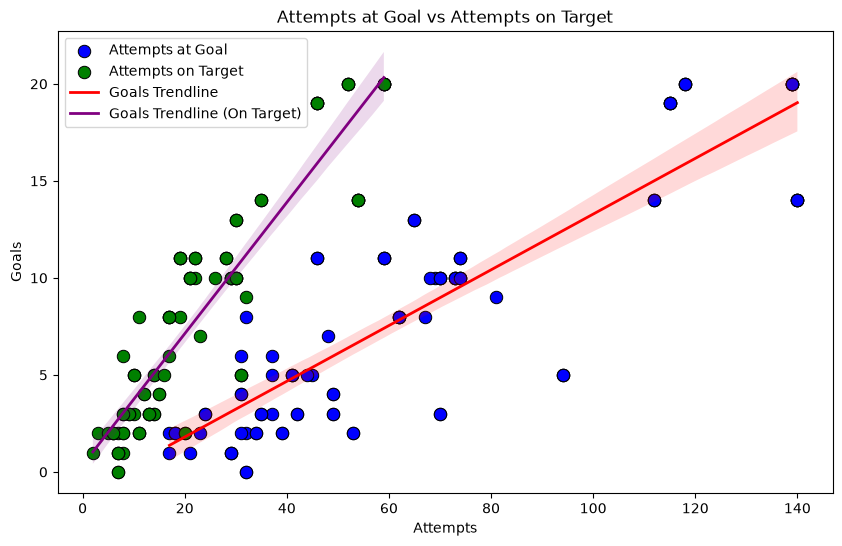

In [15]:
# Visualize shooting accuracy: attempts vs goals scored
plt.figure(figsize=(10, 6))
# Scatter plot of attempts at goal vs goals scored adding blue color for attempts at goal
sns.scatterplot(
    x=home["Attempts_at_goal"],
    y=home["Goals"],
    color="blue",
    s=80,
    edgecolor="black",
    label="Attempts at Goal"
)
# Scatter plot of attempts on target vs goals scored adding green color for attempts on target
sns.scatterplot(
    x=home["Attempts_on_target"],
    y=home["Goals"],
    color="green",
    s=80,
    edgecolor="black",
    label="Attempts on Target"
)
# Add a regression trendline for attempts at goal vs goals scored in red
sns.regplot(
    x=home["Attempts_at_goal"],
    y=home["Goals"],
    scatter=False,
    line_kws={"color": "red", "linewidth": 2},
    label="Goals Trendline"
)
# Add a regression trendline for attempts on target vs goals scored in purple
sns.regplot(
    x=home["Attempts_on_target"],
    y=home["Goals"],
    scatter=False,
    line_kws={"color": "purple", "linewidth": 2},
    label="Goals Trendline (On Target)"
)
# add labels and title for the plot
plt.xlabel("Attempts")
plt.ylabel("Goals")
plt.title("Attempts at Goal vs Attempts on Target")
plt.legend()
plt.show()


In [7]:
# Prefix home team columns to distinguish from away team
home_cols_map = {
    "Goals": "home_Goals",
    "Attempts_at_goal": "home_Attempts_at_goal",
    "Attempts_on_target": "home_Attempts_on_target",
    "Attempts_at_goal_conversionrate(%)": "home_ConversionRate",
    "Attempts_Inside_PenaltyArea": "home_Attempts_inside_PA",
    "Headed_Attemps_at_Goal": "home_Headed_attempts",
    "xG": "home_xG",
    "Possession_Control(%)": "home_Possession",
    "xG_Efficiency_num": "home_xG_eff"
}
home.rename(columns=home_cols_map, inplace=True)



In [8]:
# Merge away team statistics to create full match dataset
full = home.merge(
    team_stats,
    left_on="awaySquadAbbr",
    right_on="TeamAbbr",
    how="left",
    suffixes=("", "_away")
)



In [9]:
# Prefix away team columns
away_cols_map = {
    "Goals": "away_Goals",
    "Attempts_at_goal": "away_Attempts_at_goal",
    "Attempts_on_target": "away_Attempts_on_target",
    "Attempts_at_goal_conversionrate(%)": "away_ConversionRate",
    "Attempts_Inside_PenaltyArea": "away_Attempts_inside_PA",
    "Headed_Attemps_at_Goal": "away_Headed_attempts",
    "xG": "away_xG",
    "Possession_Control(%)": "away_Possession",
    "xG_Efficiency_num": "away_xG_eff"
}
full.rename(columns=away_cols_map, inplace=True)



In [10]:
# Create difference features (home minus away) to capture home team advantage
full["diff_goals_scored"] = full["home_Goals"] - full["away_Goals"]
full["diff_attempts_at_goal"] = full["home_Attempts_at_goal"] - full["away_Attempts_at_goal"]
full["diff_attempts_on_target"] = full["home_Attempts_on_target"] - full["away_Attempts_on_target"]
full["diff_conversion_rate"] = full["home_ConversionRate"] - full["away_ConversionRate"]
full["diff_attempts_inside_pa"] = full["home_Attempts_inside_PA"] - full["away_Attempts_inside_PA"]
full["diff_headed_attempts"] = full["home_Headed_attempts"] - full["away_Headed_attempts"]
full["diff_xG"] = full["home_xG"] - full["away_xG"]
full["diff_possession"] = full["home_Possession"] - full["away_Possession"]

In [11]:
feature_cols = [
    "diff_goals_scored",
    "diff_attempts_at_goal",
    "diff_attempts_on_target",
    "diff_conversion_rate",
    "diff_attempts_inside_pa",
    "diff_headed_attempts",
    "diff_xG",
    "diff_possession"
]

In [16]:
# Display the first few rows of the full dataset and its information
full.info()
full.head()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 68 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                104 non-null    int64  
 1   voteStatus                        104 non-null    str    
 2   stage                             104 non-null    str    
 3   roundName                         104 non-null    str    
 4   votingStartDate                   104 non-null    str    
 5   votingEndDate                     104 non-null    str    
 6   votingOpenedAt                    104 non-null    str    
 7   selectedFormation                 2 non-null      str    
 8   winners                           104 non-null    str    
 9   formations                        2 non-null      str    
 10  id.1                              104 non-null    int64  
 11  venueName                         104 non-null    str    
 12  venueCity          

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,Corners_away,away_Possession,diff_goals_scored,diff_attempts_at_goal,diff_attempts_on_target,diff_conversion_rate,diff_attempts_inside_pa,diff_headed_attempts,diff_xG,diff_possession
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,11,46,8,31,10,9,31,8,5.62,2
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,37,0,-2,3,0,-1,-1,0.94,19
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,40,0,57,17,-9,39,8,5.28,13
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,10,27,8,24,11,10,30,8,4.38,25
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,28,49,-8,-57,-24,-2,-40,-5,-7.71,-18


In [ ]:
# Separate the explanatory variable (x) from the response variable (y)
x1 = full[['diff_attempts_at_goal']].values  # explanatory variable (x)
y1 = full['diff_goals_scored'].values  # response variable (y)

In [35]:
# sequence of the data is shuffled and split into training and testing sets. 
# 60% of the data is used for training and 40% for testing.
x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.4)

In [36]:
# build the linear regression model using the training data
model = LinearRegression()
model.fit(x_train, y_train)

print("Intercept (b_0): ", model.intercept_)
print("Coefficient of X (b_1): ", model.coef_)

Intercept (b_0):  0.29804909651805356
Coefficient of X (b_1):  [0.14161251]


In [37]:
# use linear regression to predict the values of Y in the test set
y_pred = model.predict(x_test)
df_pred = pd.DataFrame({"Actual": y_test, 
                        "Predicted": y_pred})

print(df_pred)

    Actual  Predicted
0        3  -0.126788
1        8   5.679324
2       -6  -0.410013
3        0   8.369962
4        0  -0.410013
5       -5   3.838362
6       -6 -10.747726
7        3   2.847074
8      -12  -5.932901
9        2   6.104162
10       3   2.280624
11       0  -0.693238
12       8   2.705462
13      -1   2.139012
14      10   5.112874
15       8   3.696749
16       1  -2.959039
17      -9  -5.932901
18      -9  -5.508064
19       3   2.705462
20       8   4.688037
21       7   3.838362
22      11   7.095449
23      -9  -5.366451
24       1   0.581274
25      -1  -2.109364
26       1   0.722887
27       4   6.528999
28       5  -2.534201
29       0   3.271912
30       3   1.289337
31       8  15.733812
32      -8   3.696749
33      -2  -2.534201
34     -10  -6.499351
35       2   3.838362
36     -10 -11.172564
37      -4  -4.800001
38       3  11.202212
39      19  17.008325
40     -20 -11.880627
41       1  -1.967751


In [38]:
# calculate the mean absolute error (MAE), mean squared error (MSE) and root mean squared error (RMSE)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)

print("Mean Absolute Error (MAE): ", mae)
print("Mean Squared Error (MSE): ", mse)
print("Root Mean Squared Error (RMSE): ", rmse)

Mean Absolute Error (MAE):  3.6427829166360177
Mean Squared Error (MSE):  20.900936523918553
Root Mean Squared Error (RMSE):  4.571754206419955


In [39]:
# Normalize RMSE
y_max = y_test.max()
y_min = y_test.min()
nrmse = rmse / (y_max - y_min)
print("Normalized Root Mean Squared Error (NRMSE): ", nrmse)

Normalized Root Mean Squared Error (NRMSE):  0.1172244668312809


In [40]:
# construct a baseline model that takes the average of Y in training set as the basis of the prediction
y_base = np.mean(y_train)

# make prediction for every y value in the test set
y_pred_base = [y_base] * len(y_test)

# compare the baseline prediction with the actual values of Y in the test set
df_base_pred = pd.DataFrame({"Actual": y_test,
                             "Predicted": y_pred_base})

print(df_base_pred)

    Actual  Predicted
0        3   2.225806
1        8   2.225806
2       -6   2.225806
3        0   2.225806
4        0   2.225806
5       -5   2.225806
6       -6   2.225806
7        3   2.225806
8      -12   2.225806
9        2   2.225806
10       3   2.225806
11       0   2.225806
12       8   2.225806
13      -1   2.225806
14      10   2.225806
15       8   2.225806
16       1   2.225806
17      -9   2.225806
18      -9   2.225806
19       3   2.225806
20       8   2.225806
21       7   2.225806
22      11   2.225806
23      -9   2.225806
24       1   2.225806
25      -1   2.225806
26       1   2.225806
27       4   2.225806
28       5   2.225806
29       0   2.225806
30       3   2.225806
31       8   2.225806
32      -8   2.225806
33      -2   2.225806
34     -10   2.225806
35       2   2.225806
36     -10   2.225806
37      -4   2.225806
38       3   2.225806
39      19   2.225806
40     -20   2.225806
41       1   2.225806


In [42]:
# calculate the error metrics for the baseline model
mae = metrics.mean_absolute_error(y_test, y_pred_base)
mse = metrics.mean_squared_error(y_test, y_pred_base)
rmse = math.sqrt(mse)
# Normalize RMSE
y_max = y_test.max()
y_min = y_test.min()
nrmse = rmse / (y_max - y_min)
# print the error metrics for the baseline model
print("MAE of baseline model: ", mae)
print("MSE of baseline model: ", mse)
print("RMSE of baseline model: ", rmse)
print("NRMSE of baseline model: ", nrmse)

MAE of baseline model:  5.614439324116743
MSE of baseline model:  56.941925573559296
RMSE of baseline model:  7.54598738228201
NRMSE of baseline model:  0.19348685595594897


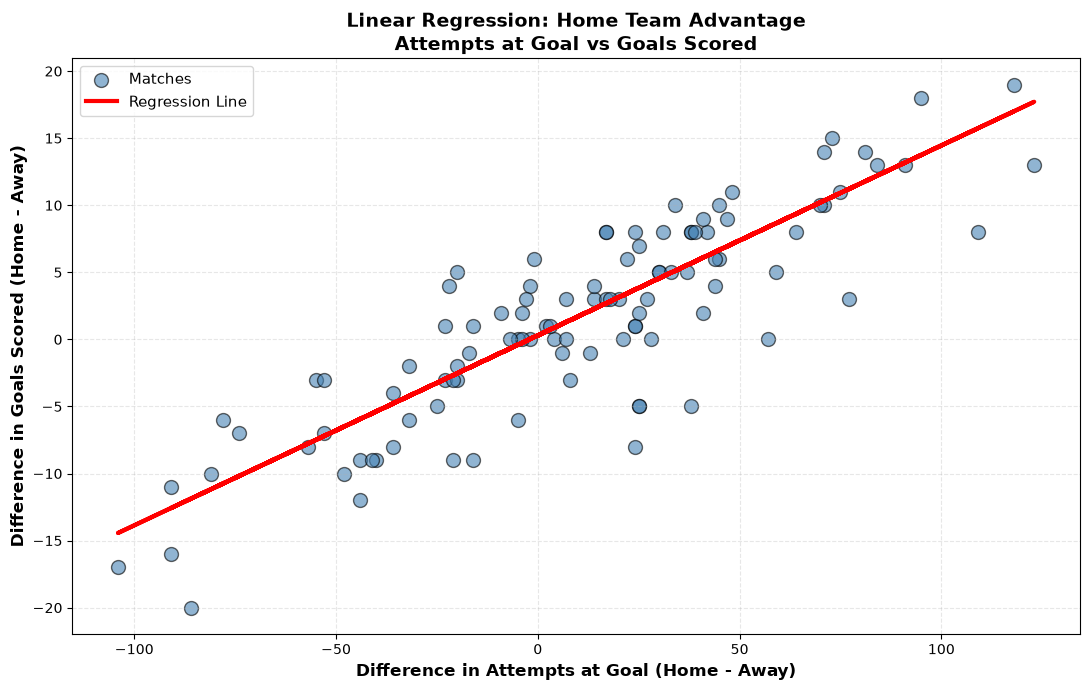

In [44]:
# Main visualization: Scatter plot with fitted regression line
plt.figure(figsize=(11, 7))
plt.scatter(x1, y1, alpha=0.6, s=100, color='steelblue', edgecolor='black', label='Matches')
plt.plot(x1, model.predict(x1), color='red', linewidth=3, label='Regression Line')

plt.xlabel('Difference in Attempts at Goal (Home - Away)', fontsize=12, fontweight='bold')
plt.ylabel('Difference in Goals Scored (Home - Away)', fontsize=12, fontweight='bold')
plt.title('Linear Regression: Home Team Advantage\nAttempts at Goal vs Goals Scored', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

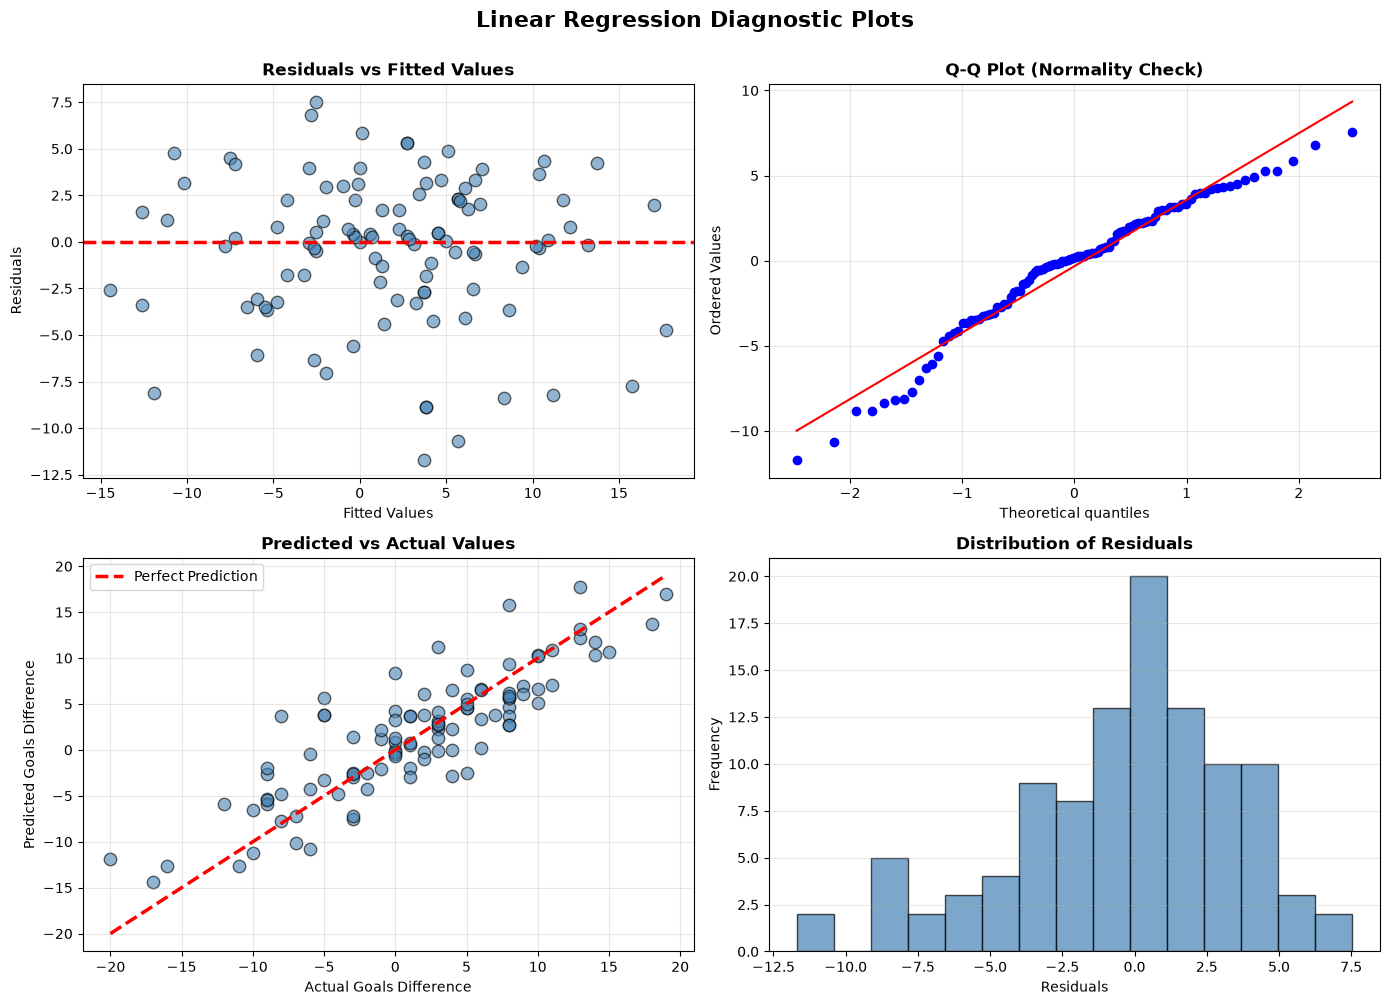


LINEAR REGRESSION MODEL SUMMARY
Intercept (b₀): 0.2980
Slope (b₁): 0.1416

R² Score (Training): 0.8026
R² Score (Testing): 0.6056
R² Score (Full Data): 0.7320

Interpretation:
For every additional attempt at goal (home vs away),
the home team scores 0.1416 more goals on average.


In [45]:
# Diagnostic plots to validate model assumptions
from scipy import stats

# Calculate predictions and residuals on full dataset
y_pred_full = model.predict(x1)
residuals = y1 - y_pred_full.flatten()

# Create 2x2 subplot for diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Diagnostic Plots', fontsize=16, fontweight='bold', y=1.00)

# 1. Residuals vs Fitted Values
axes[0, 0].scatter(y_pred_full, residuals, alpha=0.6, s=80, edgecolor='black', color='steelblue')
axes[0, 0].axhline(0, color='red', linewidth=2.5, linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot (Normality of Residuals)
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Predicted vs Actual
axes[1, 0].scatter(y1, y_pred_full, alpha=0.6, s=80, edgecolor='black', color='steelblue')
axes[1, 0].plot([y1.min(), y1.max()], [y1.min(), y1.max()], 'r--', linewidth=2.5, label='Perfect Prediction')
axes[1, 0].set_title('Predicted vs Actual Values', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Actual Goals Difference')
axes[1, 0].set_ylabel('Predicted Goals Difference')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Histogram of Residuals
axes[1, 1].hist(residuals, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print model statistics
print("\n" + "="*60)
print("LINEAR REGRESSION MODEL SUMMARY")
print("="*60)
print(f"Intercept (b₀): {model.intercept_:.4f}")
print(f"Slope (b₁): {model.coef_[0]:.4f}")
print(f"\nR² Score (Training): {model.score(x_train, y_train):.4f}")
print(f"R² Score (Testing): {model.score(x_test, y_test):.4f}")
print(f"R² Score (Full Data): {model.score(x1, y1):.4f}")
print(f"\nInterpretation:")
print(f"For every additional attempt at goal (home vs away),")
print(f"the home team scores {model.coef_[0]:.4f} more goals on average.")
print("="*60)
